# 02 — Baseline Models & Flat XAI (SHAP / LIME)
**Assumptions:** reduced capacity for fast iteration (XGB 60 rounds, RF 40 trees);
the final pipeline uses full settings. `random_state=42`.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", palette="colorblind", context="notebook")
z = np.load("proto_cache.npz", allow_pickle=True)
X_train, X_test = z["X_train"], z["X_test"]
y_train, y_test = z["y_train"], z["y_test"]
features, classes = list(z["features"]), list(z["classes"])
print(X_train.shape, "->", len(classes), "classes")

(97279, 68) -> 7 classes


In [2]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

xgb = XGBClassifier(n_estimators=60, max_depth=8, learning_rate=0.1,
                    tree_method="hist", n_jobs=2, random_state=42,
                    eval_metric="mlogloss").fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=40, max_depth=20, n_jobs=2,
                            random_state=42, class_weight="balanced").fit(X_train, y_train)
print("trained")

trained


In [3]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score)

def scores(model, name):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)
    return pd.Series({
        "accuracy": accuracy_score(y_test, pred),
        "precision_macro": precision_score(y_test, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, pred, average="macro", zero_division=0),
        "roc_auc_ovr": roc_auc_score(y_test, proba, multi_class="ovr", average="macro"),
    }, name=name)

pd.concat([scores(xgb, "XGBoost"), scores(rf, "RandomForest")], axis=1).round(4)

,XGBoost,RandomForest
accuracy,0.9990,0.9989
precision_macro,0.9983,0.9981
recall_macro,0.9981,0.9983
f1_macro,0.9982,0.9982
roc_auc_ovr,1.0000,1.0000


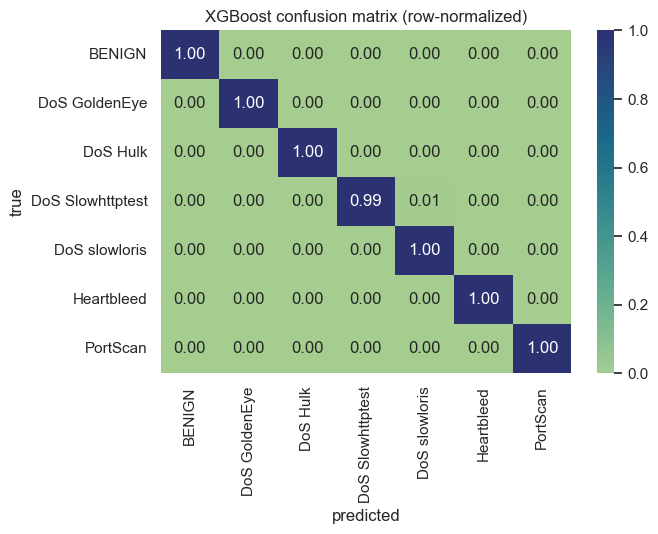

In [4]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, xgb.predict(X_test), normalize="true")
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="crest",
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("XGBoost confusion matrix (row-normalized)")
plt.tight_layout()

## Flat SHAP — the baseline HX is measured against

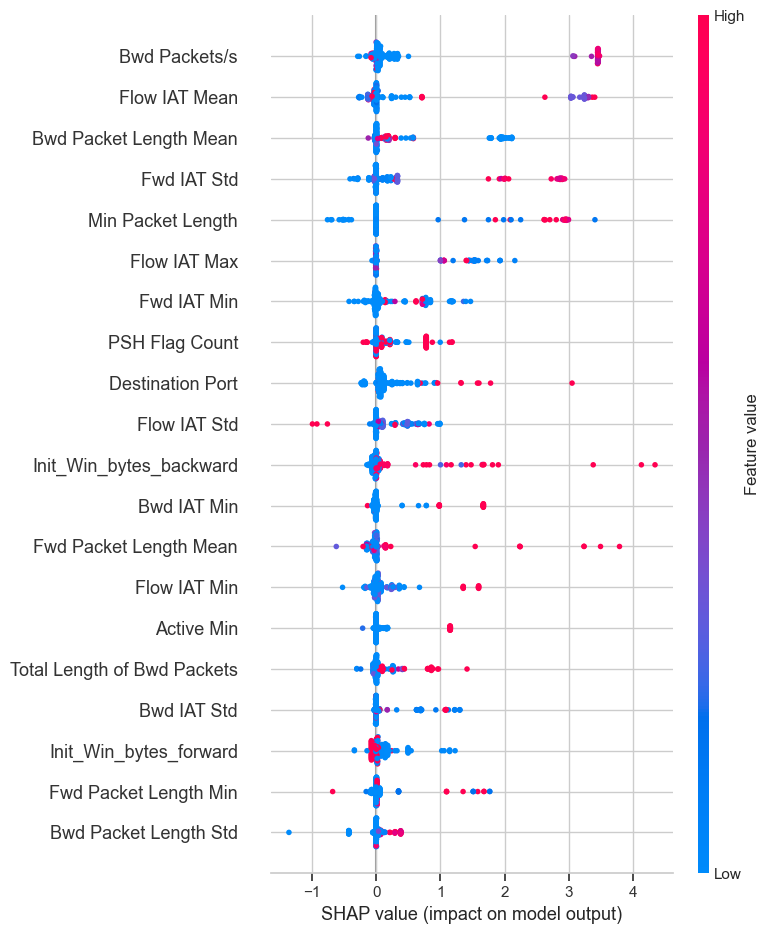

In [5]:
import shap
rng = np.random.default_rng(42)
eval_idx = np.concatenate([rng.choice(np.where(y_test == c)[0],
                                      min(40, (y_test == c).sum()), replace=False)
                           for c in np.unique(y_test)])
X_eval, y_eval = X_test[eval_idx], y_test[eval_idx]
explainer = shap.TreeExplainer(xgb)
sv = np.asarray(explainer.shap_values(X_eval))      # (n, features, classes)
preds = xgb.predict(X_eval)
sv_pred = sv[np.arange(len(X_eval)), :, preds]      # attribution for predicted class
shap.summary_plot(sv_pred, X_eval, feature_names=features, max_display=20)

> This is the analyst's problem in one picture: attribution is scattered across
> 70 features with no structural grouping — the cognitive load HX aims to reduce.

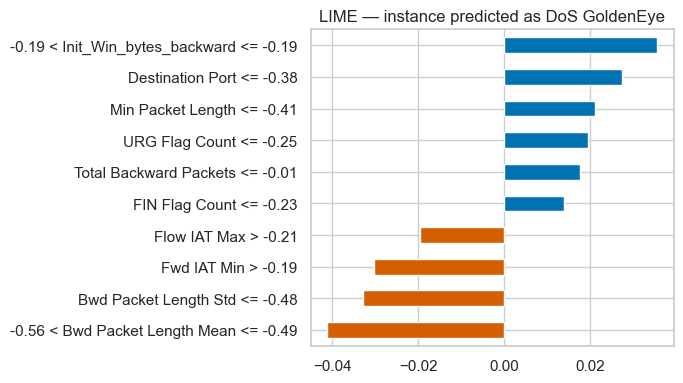

In [6]:
from lime.lime_tabular import LimeTabularExplainer
lime_exp = LimeTabularExplainer(X_train, feature_names=features,
                                class_names=classes, discretize_continuous=True,
                                random_state=42)
attack_i = int(np.where(y_eval != classes.index("BENIGN"))[0][0])
exp = lime_exp.explain_instance(X_eval[attack_i], xgb.predict_proba, num_features=10)
lbl = exp.available_labels()[0]
weights = pd.Series(dict(exp.as_list(label=lbl))).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
weights.plot.barh(ax=ax, color=np.where(weights > 0, "#0173b2", "#d55e00"))
ax.set_title(f"LIME — instance predicted as {classes[preds[attack_i]]}")
plt.tight_layout()

In [7]:
xgb.save_model("proto_xgb.json")    
print("model cached")

model cached
